# Data Preparation and Data Cleaning

In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
data_uci = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = data_uci.data.features # type: ignore # tyoe: ignore
y = data_uci.data.targets  # type: ignore
  
# metadata 
print(data_uci.metadata) 
  
# variable information 
print(data_uci.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

# EDA



In [2]:

# 1. Lista explícita de tus variables categóricas demográficas y demas
X_cat = ['X3', 'X2', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11']

X_num = [col for col in X.columns if col not in X_cat]

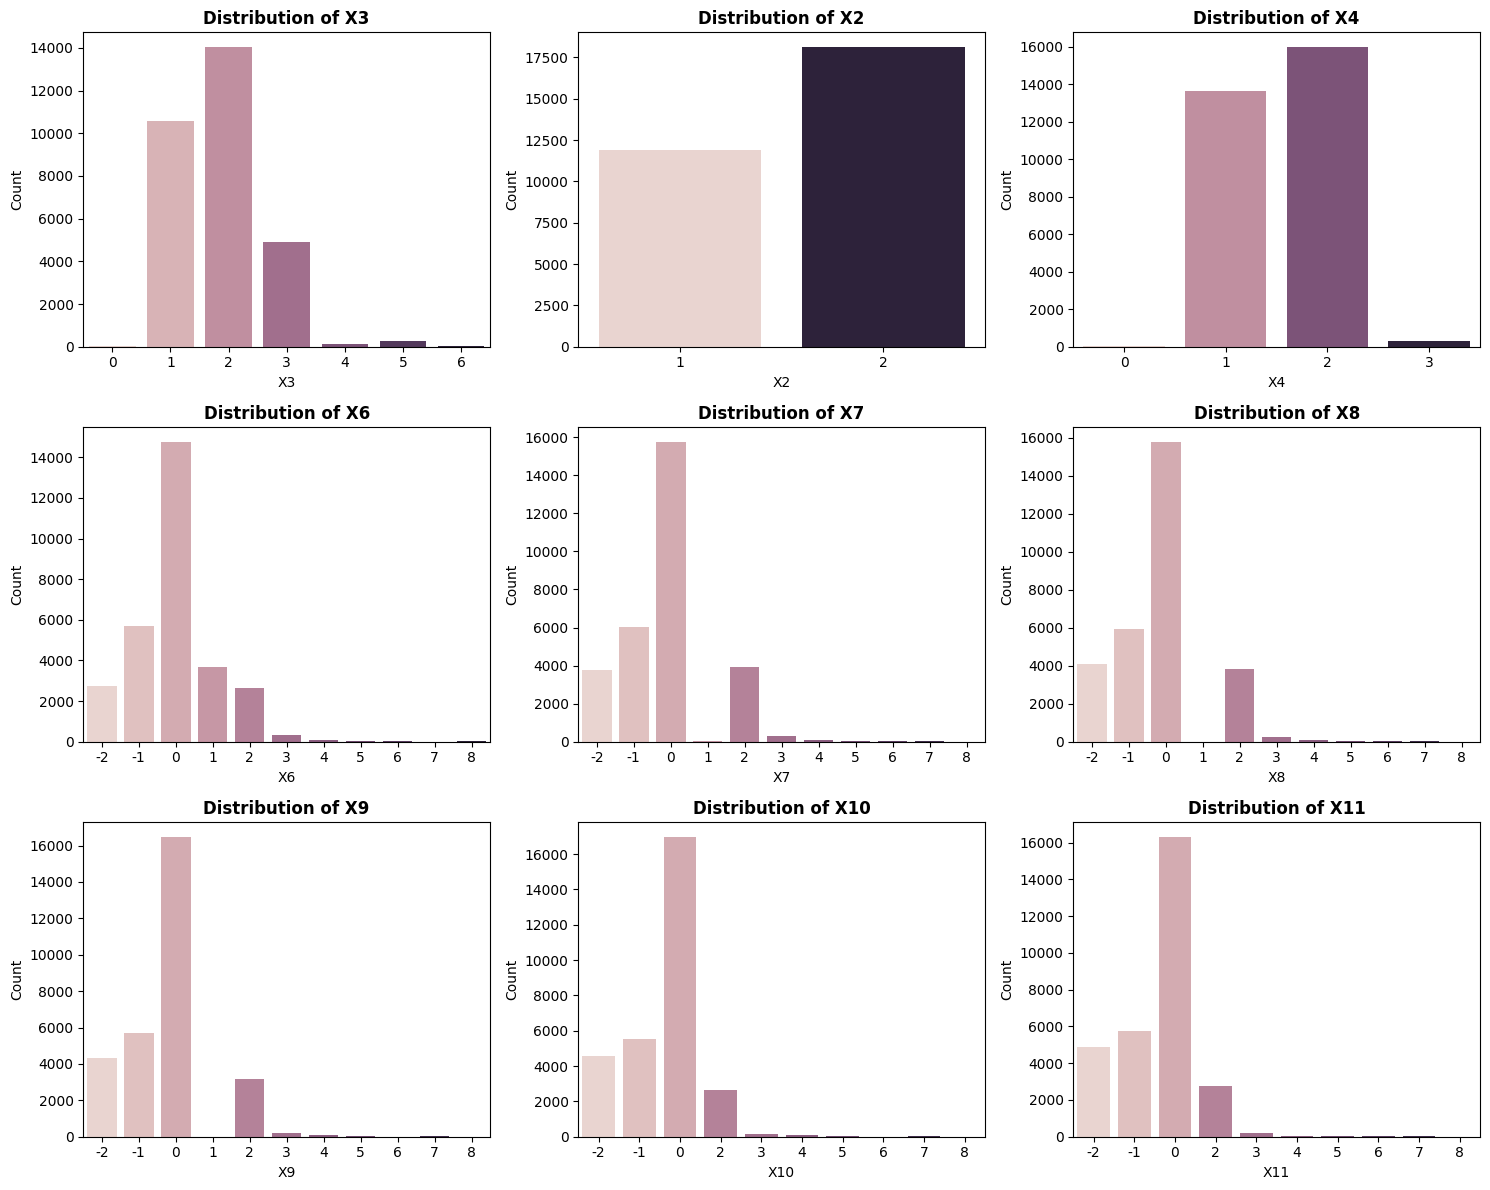

In [3]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_plots = len(X_cat)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4* n_rows))

if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(X_cat):
    ax = axes[i]
    
    counts = X[col].value_counts().sort_values(ascending=False)
    

    sns.barplot(x=counts.index, y=counts.values, ax=ax, hue=counts.index, legend=False)
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150)

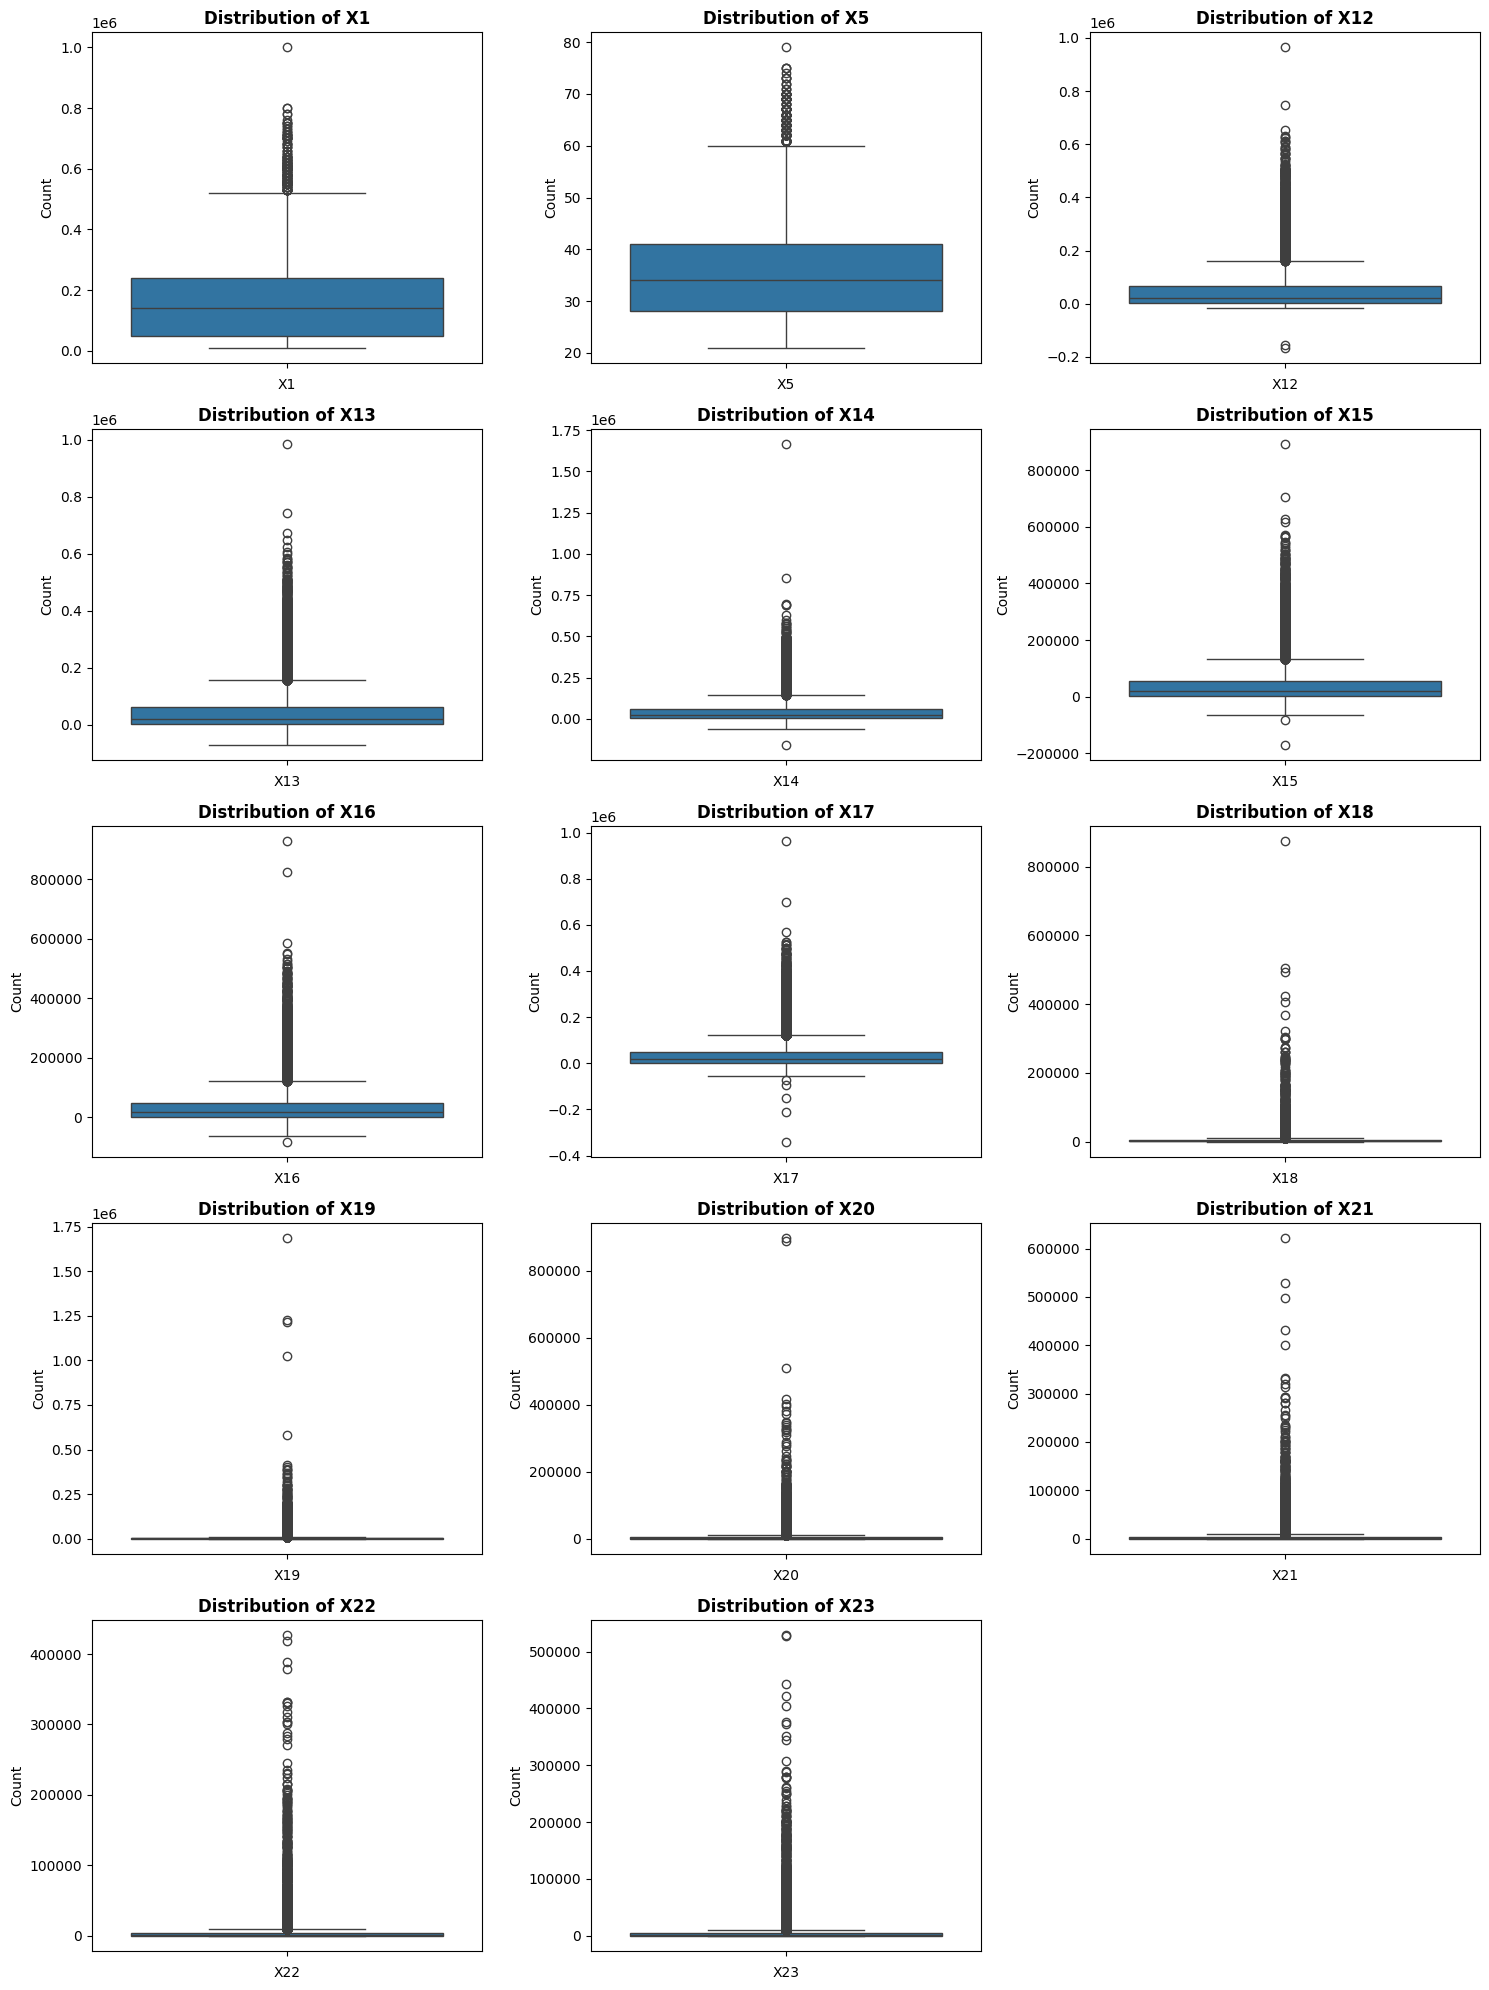

In [4]:
n_cols = 3
n_plots = len(X_num)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4* n_rows))

if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(X_num):
    ax = axes[i]
    
    

    sns.boxplot(X[col], ax=ax)
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150)

C:\Users\juane\AppData\Local\Temp\ipykernel_15780\2749962686.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Y', data=y, palette='viridis')


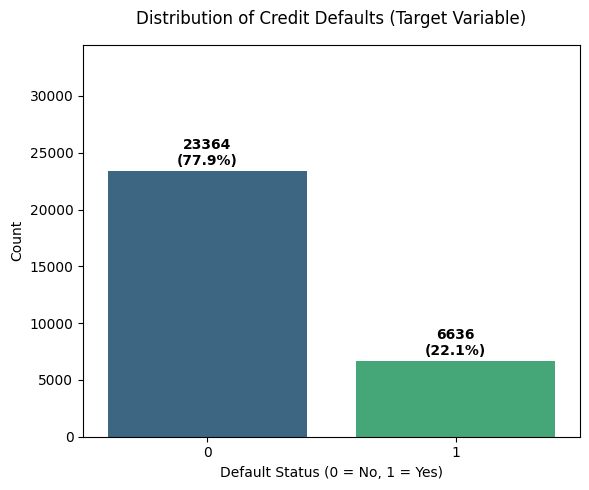

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

# 1. Capture the axes object ('ax') from the plot
ax = sns.countplot(x='Y', data=y, palette='viridis')

# 2. Calculate the total number of observations for percentage math
total = len(y)

# 3. Loop through the bars (patches) and add text labels
for p in ax.patches:
    # Get the height of each bar (which is the count)
    count = int(p.get_height())
    # Calculate the percentage relative to the dataset total
    percentage = f'{100 * count / total:.1f}%'
    
    # Combine count and percentage into a two-line string
    label = f'{count}\n({percentage})'
    
    # Position the text at the top-center of each bar
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = count + (total * 0.01) # Small padding above the bar
    
    ax.text(x_pos, y_pos, label, ha='center', va='bottom', fontsize=10, weight='bold')

plt.title("Distribution of Credit Defaults (Target Variable)", fontsize=12, pad=15)
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Dynamically boost the y-axis limit slightly so text labels don't get clipped off the top
plt.ylim(0, total * 1.15)

plt.tight_layout()
plt.show()

In [6]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='object')

Y           0          1
X6                      
-2  86.770569  13.229431
-1  83.221949  16.778051
 0  87.188709  12.811291
 1  66.052061  33.947939
 2  30.858643  69.141357
 3  24.223602  75.776398
 4  31.578947  68.421053
 5  50.000000  50.000000
 6  45.454545  54.545455
 7  22.222222  77.777778
 8  42.105263  57.894737


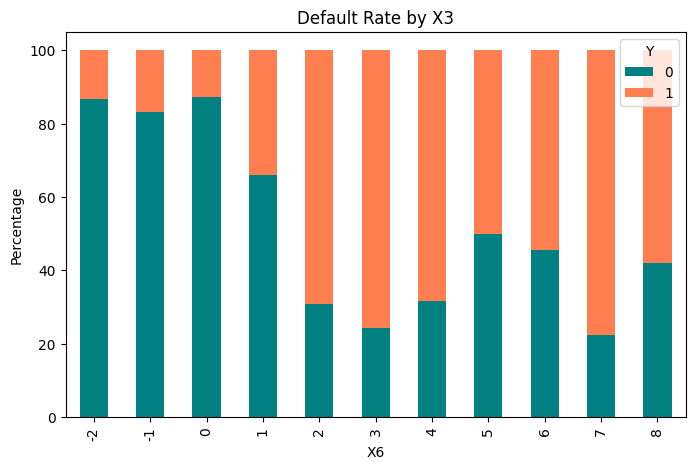

In [7]:
# Assuming X_cat[0] is a categorical variable like Education or Gender
crosstab = pd.crosstab(X['X6'], y.squeeze(), normalize='index') * 100
print(crosstab)

# Plot as a stacked bar chart
crosstab.plot(kind='bar', stacked=True, color=['teal', 'coral'], figsize=(8, 5))
plt.title(f'Default Rate by {X_cat[0]}')
plt.ylabel('Percentage')
plt.show()

# Feature Eng.

In [8]:
# since we have from x6-x11 ordinal data we need to apply OrdinalEcoder

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# over the 6 month the client has ever been late
X['ever_late'] = (X[['X6','X7','X8','X9','X10','X11']] >= 1).any(axis=1).astype(int)

# the max delay observed
X['max_delay'] = X[['X6','X7','X8','X9','X10','X11']].clip(lower=0).max(axis=1)

# is this improving or not?
X['delay_trend'] = X['X11'] - X['X6']  

# good performace ratio over the past 6 months
good = (X[['X6','X7','X8','X9','X10','X11']] <= -1)
X['good_payment_ratio'] = good.sum(axis=1) / 6

X_repayment = ['X6', 'X7', 'X8', 'X9', 'X10', 'X11']
X_derived   = ['ever_late', 'max_delay', 'delay_trend', 'good_payment_ratio']

# Expanded to include 9 and 10 which are present in your dataset
single_repayment_order = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Create a list of 6 lists (one for each of the 6 columns)
repayment_categories = [single_repayment_order for _ in range(6)] 



C:\Users\juane\AppData\Local\Temp\ipykernel_15780\1471956100.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ever_late'] = (X[['X6','X7','X8','X9','X10','X11']] >= 1).any(axis=1).astype(int)


# feature importance analysis

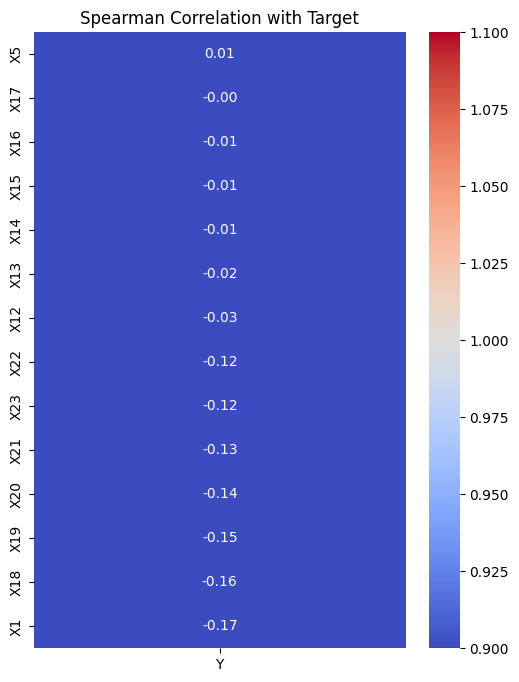

In [9]:
from scipy.stats import spearmanr
corr_df = pd.concat([X[X_num], y], axis=1)
corr_matrix, p_values = spearmanr(corr_df)
corr_df_ = pd.DataFrame(corr_matrix, index=corr_df.columns, columns=corr_df.columns)

target_corr = corr_df_[['Y']].drop('Y').sort_values(by='Y', ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=1, vmax=1, fmt='.2f')
plt.title("Spearman Correlation with Target")
plt.show()


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


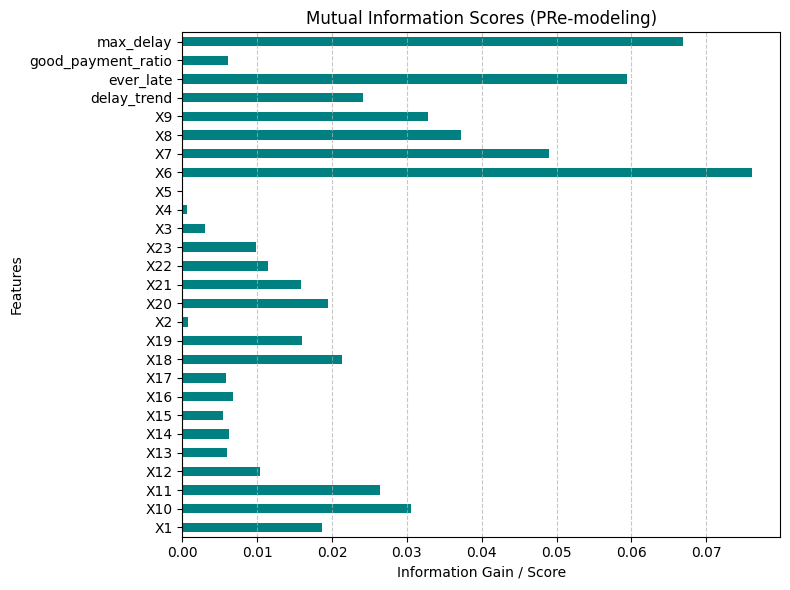

In [10]:
from sklearn.feature_selection import  mutual_info_classif

categorical_cols = X_cat + X_derived
discrete_mask = [col in categorical_cols for col in X.columns]
mi_scores = mutual_info_classif(X,y, discrete_features=discrete_mask)

mi_scores = pd.Series(mi_scores, name='Mi Scores', index=X.columns)
mi_scores = mi_scores.sort_index(ascending=True)


plt.figure(figsize=(8,6))
mi_scores.plot(kind='barh', color='teal')
plt.title("Mutual Information Scores (PRe-modeling)")
plt.xlabel("Information Gain / Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Model selection


In [11]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
import time, joblib, os, tempfile
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler


def make_pipeline(clf):
    return Pipeline([
        ('pre', ColumnTransformer(transformers=[
            ('num', RobustScaler(), X_num),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), X_cat),
            ('rep', OrdinalEncoder(categories=repayment_categories, handle_unknown='use_encoded_value', unknown_value=-1), X_repayment),
            ('der', RobustScaler(), X_derived),
        ])),
        ('clf', clf)
    ])




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.squeeze(),
    test_size=0.2,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # for xgboost

results = {}

models = {
    'Logistic Regression':  make_pipeline(LogisticRegression(class_weight='balanced', max_iter=1000)),
    'Random Forest':        make_pipeline(RandomForestClassifier(class_weight='balanced', n_jobs=-1)),
    'HistGradientBoosting': make_pipeline(HistGradientBoostingClassifier(class_weight='balanced')),
    'XGBoost':              make_pipeline(XGBClassifier(scale_pos_weight=scale_pos_weight,
                                                        eval_metric='logloss', n_jobs=-1)),
    'LightGBM':             make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1)),
    'VotingClassifier':     VotingClassifier(estimators=[
                                ('lr',   make_pipeline(LogisticRegression(class_weight='balanced'))),
                                ('hgb',  make_pipeline(HistGradientBoostingClassifier(class_weight='balanced'))),
                                ('lgbm', make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1))),
                            ], voting='soft', n_jobs=-1),
}
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}


results = {}
for name, model in models.items():
    start = time.time()
    cv_results = cross_validate(
        model, X, y.values.ravel().astype(int),         
        cv=StratifiedKFold(5),
        scoring=scoring_metrics,
        return_train_score=True
    )
    elapsed = time.time() - start

    model.fit(X_train, y_train)         
    with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
        tmp_path = f.name
    joblib.dump(model, tmp_path)
    pkl_kb = os.path.getsize(tmp_path) / 1024
    os.unlink(tmp_path)

    results[name] = {
        'accuracy_mean':  cv_results['test_accuracy'].mean(),
        'precision_mean': cv_results['test_precision'].mean(),
        'recall_mean':    cv_results['test_recall'].mean(),
        'f1_mean':        cv_results['test_f1'].mean(),
        'roc_auc_mean':        cv_results['test_roc_auc'].mean(),
        'overfit_gap':    round(cv_results['train_f1'].mean() - cv_results['test_f1'].mean(), 3),
        'train_time_s':   round(elapsed, 1),
        'pkl_kb':         round(pkl_kb, 1),
    }

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.p

[LightGBM] [Info] Number of positive: 5308, number of negative: 18692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3377
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3372
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but 

...

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3378
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001738 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3378
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-defaul

In [12]:
df = pd.DataFrame(results).T

df.index.name = 'Model'

# 1. ADD 'roc_auc_mean' to the column selection
df = df[['roc_auc_mean', 'f1_mean', 'precision_mean', 'recall_mean', 'accuracy_mean', 'overfit_gap', 'train_time_s', 'pkl_kb']]

# 2. ADD 'ROC AUC' to the column renaming
df.columns = ['ROC AUC', 'F1', 'Precision', 'Recall', 'Accuracy', 'Overfit Gap', 'Train Time (s)', 'PKL (KB)']

# cast to float so styling works
df = df.astype(float)

def highlight_table(df):
    styled = df.style

    # metrics where higher = better (green scale)
    for col in ['ROC AUC', 'F1', 'Precision', 'Recall', 'Accuracy']:
        styled = styled.background_gradient(cmap='Greens', subset=[col], vmin=0, vmax=1)

    # metrics where lower = better (reverse green = red for high values)
    for col in ['Overfit Gap', 'Train Time (s)', 'PKL (KB)']:
        styled = styled.background_gradient(cmap='RdYlGn_r', subset=[col])

    styled = styled.format({
        'F1':           '{:.3f}',
        'Precision':    '{:.3f}',
        'Recall':       '{:.3f}',
        'Accuracy':     '{:.3f}',
        'Overfit Gap':  '{:.3f}',
        'Train Time (s)': '{:.1f}',
        'PKL (KB)':     '{:,.0f}',
    })

    return styled

highlight_table(df)

,ROC AUC,F1,Precision,Recall,Accuracy,Overfit Gap,Train Time (s),PKL (KB)
Model,,,,,,,,
Logistic Regression,0.769428,0.531,0.467,0.615,0.759,0.002,8.6,8
Random Forest,0.764385,0.523,0.558,0.494,0.801,0.468,6.7,"69,956"
HistGradientBoosting,0.782983,0.534,0.461,0.634,0.754,0.041,13.5,244
XGBoost,0.761825,0.513,0.459,0.584,0.755,0.247,3.0,395
LightGBM,0.780553,0.536,0.468,0.628,0.759,0.095,2.7,350
VotingClassifier,0.784115,0.538,0.478,0.617,0.765,0.045,27.2,553


# Tuning best model

In [13]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # --- Tune Logistic Regression ---
    lr_c = trial.suggest_float("lr_C", 1e-4, 10.0, log=True)
    lr_pipeline = make_pipeline(
        LogisticRegression(C=lr_c, class_weight="balanced", random_state=42)
    )

    # --- Tune HistGradientBoosting ---
    hgb_lr = trial.suggest_float("hgb_learning_rate", 0.01, 0.2, log=True)
    hgb_max_iter = trial.suggest_int("hgb_max_iter", 50, 200)
    hgb_pipeline = make_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=hgb_lr,
            max_iter=hgb_max_iter,
            class_weight="balanced",
            random_state=42,
        )
    )

    # --- Tune LGBMClassifier ---
    lgbm_lr = trial.suggest_float("lgbm_learning_rate", 0.01, 0.2, log=True)
    lgbm_n_est = trial.suggest_int("lgbm_n_estimators", 50, 200)
    lgbm_num_leaves = trial.suggest_int("lgbm_num_leaves", 15, 63)
    lgbm_pipeline = make_pipeline(
        LGBMClassifier(
            learning_rate=lgbm_lr,
            n_estimators=lgbm_n_est,
            num_leaves=lgbm_num_leaves,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
            verbosity=-1,  # Keeps the logs clean
        )
    )

    # --- Tune Voting Weights (Optional but highly recommended) ---
    w_lr = trial.suggest_float("w_lr", 0.0, 1.0)
    w_hgb = trial.suggest_float("w_hgb", 0.0, 1.0)
    w_lgbm = trial.suggest_float("w_lgbm", 0.0, 1.0)

    # 3. Construct the VotingClassifier with trial parameters
    ensemble = VotingClassifier(
        estimators=[
            ("lr", lr_pipeline),
            ("hgb", hgb_pipeline),
            ("lgbm", lgbm_pipeline),
        ],
        voting="soft",
        weights=[w_lr, w_hgb, w_lgbm],
        n_jobs=-1,
    )

    # 4. Evaluate using Cross-Validation
    # Using roc_auc because class_weight='balanced' implies an imbalanced dataset
    score = cross_val_score(
        ensemble, X, y, cv=5, scoring="roc_auc", n_jobs=-1
    ).mean()

    return score

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n--- Optimization Finished ---")
print(f"Best Trial Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-09 21:22:23,885] A new study created in memory with name: no-name-b3ce22b5-76e1-4bdd-9feb-570107d3a43c
[I 2026-06-09 21:22:36,351] Trial 0 finished with value: 0.7819905824486948 and parameters: {'lr_C': 0.09504578467463703, 'hgb_learning_rate': 0.01637055536260778, 'hgb_max_iter': 100, 'lgbm_learning_rate': 0.03256653587556302, 'lgbm_n_estimators': 121, 'lgbm_num_leaves': 16, 'w_lr': 0.5574160073183172, 'w_hgb': 0.7164911852218706, 'w_lgbm': 0.21255251182039425}. Best is trial 0 with value: 0.7819905824486948.
[I 2026-06-09 21:22:45,499] Trial 1 finished with value: 0.7840276796158673 and parameters: {'lr_C': 0.0008528969849357933, 'hgb_learning_rate': 0.1986119540636003, 'hgb_max_iter': 96, 'lgbm_learning_rate': 0.025931016338519873, 'lgbm_n_estimators': 195, 'lgbm_num_leaves': 28, 'w_lr': 0.04022641890938927, 'w_hgb': 0.22684085400341414, 'w_lgbm': 0.7796663051253749}. Best is trial 1 with value: 0.7840276796158673.
[I 2026-06-09 21:22:59,555] Trial 2 finished with value:


--- Optimization Finished ---
Best Trial Score: 0.7845
Best Hyperparameters:
  lr_C: 0.4148334003723113
  hgb_learning_rate: 0.03857484170147795
  hgb_max_iter: 141
  lgbm_learning_rate: 0.0640219730972969
  lgbm_n_estimators: 183
  lgbm_num_leaves: 59
  w_lr: 0.37637753588605427
  w_hgb: 0.8777541874819587
  w_lgbm: 0.4069606031812729


# Tuning 2d best model

In [15]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    # --- Tune LGBMClassifier ---
    lgbm_lr = trial.suggest_float("lgbm_learning_rate", 0.01, 0.2, log=True)
    lgbm_n_est = trial.suggest_int("lgbm_n_estimators", 50, 200)
    lgbm_num_leaves = trial.suggest_int("lgbm_num_leaves", 15, 63)
    lgbm_pipeline = make_pipeline(
        LGBMClassifier(
            learning_rate=lgbm_lr,
            n_estimators=lgbm_n_est,
            num_leaves=lgbm_num_leaves,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
            verbosity=-1,  # Keeps the logs clean
        )
    )


    # 4. Evaluate using Cross-Validation
    # Using roc_auc because class_weight='balanced' implies an imbalanced dataset
    score = cross_val_score(
        lgbm_pipeline, X, y, cv=5, scoring="roc_auc", n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n--- Optimization Finished ---")
print(f"Best Trial Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-09 21:28:24,204] A new study created in memory with name: no-name-b5bb1649-cf51-4f9b-bb6c-388ad3b7cb31
[I 2026-06-09 21:28:25,646] Trial 0 finished with value: 0.781784739160529 and parameters: {'lgbm_learning_rate': 0.030478207158336827, 'lgbm_n_estimators': 70, 'lgbm_num_leaves': 48}. Best is trial 0 with value: 0.781784739160529.
[I 2026-06-09 21:28:28,148] Trial 1 finished with value: 0.7813500157923187 and parameters: {'lgbm_learning_rate': 0.045778661422378436, 'lgbm_n_estimators': 172, 'lgbm_num_leaves': 43}. Best is trial 0 with value: 0.781784739160529.
[I 2026-06-09 21:28:30,560] Trial 2 finished with value: 0.7632087807974411 and parameters: {'lgbm_learning_rate': 0.1774366617056516, 'lgbm_n_estimators': 198, 'lgbm_num_leaves': 44}. Best is trial 0 with value: 0.781784739160529.
[I 2026-06-09 21:28:32,741] Trial 3 finished with value: 0.7824050934484752 and parameters: {'lgbm_learning_rate': 0.043529634406291214, 'lgbm_n_estimators': 152, 'lgbm_num_leaves': 35}. B


--- Optimization Finished ---
Best Trial Score: 0.7842
Best Hyperparameters:
  lgbm_learning_rate: 0.05998543731928019
  lgbm_n_estimators: 119
  lgbm_num_leaves: 16


In [16]:
import joblib
from sklearn.metrics import precision_recall_curve
from lightgbm import LGBMClassifier
import numpy as np

# 1. Pass the classifier directly into your custom make_pipeline function
final_pipeline = make_pipeline(
    LGBMClassifier(
        learning_rate=0.07088661041095881,
        n_estimators=68,
        num_leaves=30,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42 # Added for reproducible probabilities
    )
)

# 2. Fit on the entire training set
final_pipeline.fit(X_train, y_train)

# 3. Predict probabilities on test data to find your threshold safely
probabilidades_test = final_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_test)

f1_scores_curva = 2 * (precision * recall) / np.maximum((precision + recall), 1e-10)
indice_optimo = np.argmax(f1_scores_curva[:-1]) 
umbral_optimo = thresholds[indice_optimo]

print(f"production thresdhold: {umbral_optimo:.4f}")

# 4. Save your pristine, single-layer pipeline
joblib.dump(final_pipeline, "src/pipeline_produccion.pkl")

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3378
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
production thresdhold: 0.6154


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


['src/pipeline_produccion.pkl']

# Model evaluation with best features

In [17]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
import time, joblib, os, tempfile
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# Fix the typo and extract the exact column indexes/names
best_features_set_1 = mi_scores[mi_scores > 0.01].index.tolist()
best_features_set_2 = mi_scores[mi_scores > 0.005].index.tolist()

# You can now choose which set you want to pass to your model, e.g.:
SELECTED_FEATURES = best_features_set_2  # or best_features_set_2


def make_pipeline(clf, selected_features=SELECTED_FEATURES):
    # Dynamically filter your original lists down to ONLY what survived the MI score threshold
    current_num = [col for col in X_num if col in selected_features]
    current_cat = [col for col in X_cat if col in selected_features]
    current_der = [col for col in X_derived if col in selected_features]
    
    # Track which repayment columns survived, and map their index positions for OrdinalEncoder
    current_rep = [col for col in X_repayment if col in selected_features]
    # We only keep the matching category mapping lists for the repayment columns that actually survived
    current_rep_categories = [single_repayment_order for col in X_repayment if col in selected_features]

    # Build the transformers array list dynamically
    transformers = []
    
    if current_num:
        transformers.append(('num', RobustScaler(), current_num))
        
    if current_cat:
        transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), current_cat))
        
    if current_rep:
        transformers.append(('rep', OrdinalEncoder(categories=current_rep_categories, 
                                                   handle_unknown='use_encoded_value', 
                                                   unknown_value=-1), current_rep))
        
    if current_der:
        # Using RobustScaler here too since max_delay inherits severe outliers from X6-X11
        transformers.append(('der', RobustScaler(), current_der))

    return Pipeline([
        ('pre', ColumnTransformer(transformers=transformers, remainder='drop')),
        ('clf', clf)
    ])




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.squeeze(),
    test_size=0.2,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # for xgboost

results = {}

models = {
    'Logistic Regression':  make_pipeline(LogisticRegression(class_weight='balanced', max_iter=1000)),
    'Random Forest':        make_pipeline(RandomForestClassifier(class_weight='balanced', n_jobs=-1)),
    'HistGradientBoosting': make_pipeline(HistGradientBoostingClassifier(class_weight='balanced')),
    'XGBoost':              make_pipeline(XGBClassifier(scale_pos_weight=scale_pos_weight,
                                                        eval_metric='logloss', n_jobs=-1)),
    'LightGBM':             make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1)),
    'VotingClassifier':     VotingClassifier(estimators=[
                                ('lr',   make_pipeline(LogisticRegression(class_weight='balanced'))),
                                ('hgb',  make_pipeline(HistGradientBoostingClassifier(class_weight='balanced'))),
                                ('lgbm', make_pipeline(LGBMClassifier(class_weight='balanced', n_jobs=-1))),
                            ], voting='soft', n_jobs=-1),
}
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}


results = {}
for name, model in models.items():
    start = time.time()
    cv_results = cross_validate(
        model, X, y.values.ravel().astype(int),         
        cv=StratifiedKFold(5),
        scoring=scoring_metrics,
        return_train_score=True
    )
    elapsed = time.time() - start

    model.fit(X_train, y_train)         
    with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
        tmp_path = f.name
    joblib.dump(model, tmp_path)
    pkl_kb = os.path.getsize(tmp_path) / 1024
    os.unlink(tmp_path)

    results[name] = {
        'accuracy_mean':  cv_results['test_accuracy'].mean(),
        'precision_mean': cv_results['test_precision'].mean(),
        'recall_mean':    cv_results['test_recall'].mean(),
        'f1_mean':        cv_results['test_f1'].mean(),
        'roc_auc_mean':        cv_results['test_roc_auc'].mean(),
        'overfit_gap':    round(cv_results['train_f1'].mean() - cv_results['test_f1'].mean(), 3),
        'train_time_s':   round(elapsed, 1),
        'pkl_kb':         round(pkl_kb, 1),
    }

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.p

[LightGBM] [Info] Number of positive: 5308, number of negative: 18692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3303
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3299
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but 

...

c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3305
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001840 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3304
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-default-classifier-LqyGr6oY\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\juane\.virtualenvs\lambda-credit-defaul

In [18]:
df = pd.DataFrame(results).T

df.index.name = 'Model'

# 1. ADD 'roc_auc_mean' to the column selection
df = df[['roc_auc_mean', 'f1_mean', 'precision_mean', 'recall_mean', 'accuracy_mean', 'overfit_gap', 'train_time_s', 'pkl_kb']]

# 2. ADD 'ROC AUC' to the column renaming
df.columns = ['ROC AUC', 'F1', 'Precision', 'Recall', 'Accuracy', 'Overfit Gap', 'Train Time (s)', 'PKL (KB)']

# cast to float so styling works
df = df.astype(float)

highlight_table(df)

,ROC AUC,F1,Precision,Recall,Accuracy,Overfit Gap,Train Time (s),PKL (KB)
Model,,,,,,,,
Logistic Regression,0.767351,0.526,0.462,0.612,0.756,0.005,9.3,8
Random Forest,0.758738,0.519,0.536,0.505,0.793,0.442,6.0,"67,016"
HistGradientBoosting,0.780773,0.535,0.465,0.629,0.757,0.046,12.2,197
XGBoost,0.757566,0.514,0.460,0.582,0.756,0.237,2.7,377
LightGBM,0.777865,0.534,0.466,0.625,0.758,0.089,2.4,349
VotingClassifier,0.781461,0.538,0.478,0.615,0.766,0.041,16.1,573




model with set one features:


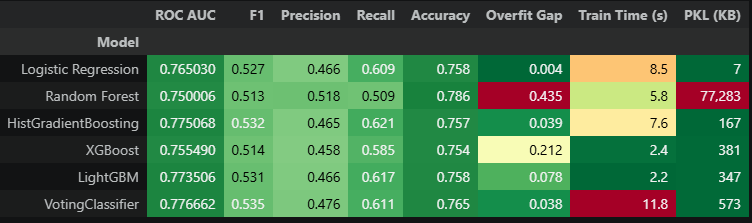

models with set two features:


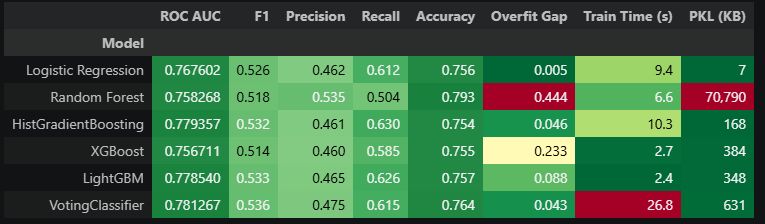

models without features selection, including feature eng:


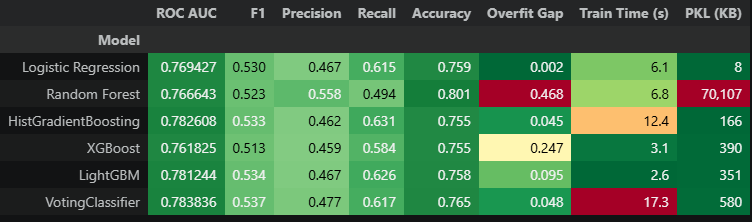